In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import os
from os.path import join
from collections import defaultdict
import numpy as np
import pandas as pd
import tqdm
from sklearn.linear_model import LinearRegression

import logging
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('euclid_stylesheet_v2.mplstyle')
mpl.rcParams['figure.dpi'] = 300

In [2]:
mdir = './saved_models'


def r2logm(r):
    # see preprocessing.ipynb for this measurement
    coef = 0.36752
    intercept = -5.30640
    return (np.log10(r)-intercept)/coef

In [3]:
datanames = ['wC50', 'wC100', 'dC50', 'dC100']
runnames = ['base', 'gals_nle', 'summ_nle', 'gnn_npe']
modelnames = ['msig', 'pamico', 'mamp', 'gals_nle', 'summ_nle', 'gnn_npe']
Nfolds = 10
folds = np.arange(Nfolds)

datatitles = dict(
    wC50='Wide $50\%$',
    wC100='Wide $100\%$',
    dC50='Deep $50\%$',
    dC100='Deep $100\%$'
)
modeltitles = dict(
    msig='$M$--$\sigma$',
    pamico=r'$M$--$\lambda_{\rm spec}$',
    mamp='MAMPOSSt',
    gals_nle='Galaxy-Net',
    summ_nle='Summary-Net',
    gnn_npe='Graph-Net',
    true='True',
    prior='Prior',
    dummy='Dummy'
)

In [4]:
from scipy.stats import skewnorm
from scipy.optimize import minimize


def fit_skewed_normal(p16, p50, p84):
    target_percentiles = [0.16, 0.50, 0.84]
    observed_values = [p16, p50, p84]

    def objective(params):
        loc, scale, alpha = params
        if scale <= 0:
            return np.inf
        skewed_gaussian = skewnorm(alpha, loc=loc, scale=scale)
        calculated_values = skewed_gaussian.ppf(target_percentiles)
        return np.sum((calculated_values - observed_values) ** 2)

    initial_guess = [p50, (p84 - p16) / 2, 0.5]
    result = minimize(objective, initial_guess)
    loc, scale, alpha = result.x
    return skewnorm(alpha, loc=loc, scale=scale)

In [5]:
# load train/test
header = 'APR24'
datadir = './data/processed'

theta, fold, ids, richs, zclus, Ngal = {}, {}, {}, {}, {}, {}
for d in datanames:
    dirpath = join(datadir, f'{header}{d}')
    print('Loading:', dirpath)
    theta[d] = np.load(join(dirpath, 'theta_batch.npy'))
    fold[d] = np.load(join(dirpath, 'folds_batch.npy'))
    ids[d] = np.load(join(dirpath, 'ids_batch.npy'))
    metas = np.load(join(dirpath, 'metas_batch.npy'))
    zclus[d] = metas[:, 3]  # cluster photometric redshift
    richs[d] = metas[:, 1]  # sum of AMICO photometry
    Ngal[d] = np.load(join(dirpath, 'x_sum.npy'))[:, -1]

Ndata = {d: len(theta[d]) for d in datanames}
print(Ndata)

Loading: ./data/processed/APR24wC50
Loading: ./data/processed/APR24wC100
Loading: ./data/processed/APR24dC50
Loading: ./data/processed/APR24dC100
{'wC50': 840, 'wC100': 907, 'dC50': 1998, 'dC100': 2014}


In [6]:
Nsamp = 100
preds = defaultdict(dict)
for d in datanames:
    for r in runnames:
        # setup
        if r == 'base':
            preds[d]['msig'] = np.ones((Ndata[d], 2))*np.nan
            preds[d]['pamico'] = np.ones((Ndata[d], 2))*np.nan
        else:
            preds[d][r] = np.full((Ndata[d], Nsamp, 1), np.nan)

        # load
        for f in folds:
            if r == 'gnn_npe':
                dirname = f'oct02_{r}_{d}_f{f}'
            else:
                dirname = f'apr24_{r}_{d}_f{f}'
            if r == 'base':
                # Msig
                samplefile = join(mdir, dirname, 'msig.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['msig'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['msig'][:, 1], place_ids, s['std'])

                # Pamico
                samplefile = join(mdir, dirname, 'Pamico.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['pamico'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['pamico'][:, 1], place_ids, s['std'])

            else:
                # ML models
                samplefile = join(mdir, dirname, 'posterior_samples.npy')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                s = np.swapaxes(s, 0, 1)
                s = s[:, :Nsamp]  # subsample if necessary
                preds[d][r][fold[d] == f] = s

In [7]:
# load mamposst

mamnames = {
    'wC50': 'wide50', 'wC100': 'wide100', 'dC50': 'deep50', 'dC100': 'deep100'
}
modeldir = './saved_models/mamposst_newprior_dec1824/'

for k, v in mamnames.items():
    isamp = pd.read_csv(join(modeldir, f'result_MockFS_NewAMICO_{v}.dat'),
                        delimiter=' ', skipinitialspace=True)
    isamp['id'] = isamp['#ClusterID'].astype(int)
    # convert r200 to logm
    for c in isamp.columns:
        if 'r200' not in c:
            continue
        isamp['logm'+c[4:]] = r2logm(isamp[c])

    # put in preds
    preds[k]['mamp'] = np.ones((Ndata[k], 5))*np.nan
    place_ids = np.searchsorted(ids[k], isamp['id'].values)
    mask = place_ids < Ndata[k]
    _s = isamp[['logmlow(68)', 'logmup(68)', 'logmlow(95)',
                'logmup(95)', 'logmMAM']].values
    preds[k]['mamp'][place_ids[mask]] = _s[mask]

In [8]:
# calculate percentiles from predictions
q = 100*np.array([0.16, 0.84, 0.5, 0.025, 0.975])
percs = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        if m == 'msig' or m == 'pamico':
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0]-t_[:, 1], t_[:, 0]+t_[:, 1], t_[:, 0],
                    t_[:, 0]-2*t_[:, 1], t_[:, 0]+2*t_[:, 1]],
                axis=1).T
        elif m == 'mamp':
            if m not in preds[d]:
                continue
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0], t_[:, 1], t_[:, 4], t_[:, 2], t_[:, 3]],
                axis=1).T
        else:
            t_ = preds[d][m]
            percs[d][m] = np.percentile(t_, q, axis=1)[..., 0]
# percs is of shape (5, Ndata)
# dim 0 is of order [16, 84, 50, 2.5, 97.5]

In [9]:
# Compute quality control
def quality_control(percs):
    # checks if we have a reasonable median prediction
    # checks if we're not missing a prediction (not nan)
    med = percs[2]
    mask = (med > 12) & (med < 16)

    err = (percs[1] - percs[0])/2
    mask &= err < 1
    return mask


qc = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        qc[d][m] = quality_control(percs[d][m])

In [10]:
# Remove Ngal < 3
for d in datanames:
    mask = Ngal[d] >= 3

    theta[d] = theta[d][mask]
    fold[d] = fold[d][mask]
    ids[d] = ids[d][mask]
    richs[d] = richs[d][mask]
    zclus[d] = zclus[d][mask]
    Ngal[d] = Ngal[d][mask]
    Ndata[d] = len(theta[d])

    for m in modelnames:
        if m not in percs[d]:
            continue
        preds[d][m] = preds[d][m][mask]
        percs[d][m] = percs[d][m][:, mask]
        qc[d][m] = qc[d][m][mask]

## MCMC -- v7: forward-calibration, grid-marginalized mass-richness

Fork of v6 (see `CLAUDE.md`). Two structural changes:

1. **Drop the cal-subset richness anchor** -- calibration clusters contribute
   only the calibration factor; their richness never enters the likelihood. So
   the M-lambda relation is fit from the main sample only (no shared-relation
   assumption).
2. **Forward calibration + explicit latent mass.** Replace the backward slope
   $\beta$ (truth-on-estimate) with the **forward** slope $b_{\rm fwd}$
   (estimate-on-truth), and make true mass an explicit latent with population
   prior $\pi(m|z)$ (= v5's $\phi(m|z)$). The relation term marginalizes mass
   on a per-cluster grid (deterministic quadrature, no MC over samples), so
   $\pi$ may be non-Gaussian.

Generative model (main cluster):
$$m_i\sim\pi(m|z_i),\quad \mu_i=a+b_{\rm fwd}(m_i-m_{\rm ref})+\eta_i,\ \eta_i\sim N(0,\omega_i^2),\ \omega_i^2=\omega_0^2+\kappa^2\sigma_i^2,$$
$$\ell_i=\pi_0+F_m(m_i-m_0)+G_z\zeta_i+\varepsilon_i,\ \varepsilon_i\sim N(0,\sigma_\lambda^2).$$

**Term 1 (calibration, cal subset):** $\sum_c \ln N(\mu_c;\,a+b_{\rm fwd}(m_{{\rm true},c}-m_{\rm ref}),\,\omega_c^2)$.

**Term 2 (main, conditional, grid-marginalized):**
$\ln L_{{\rm main},i}=\mathrm{LSE}_g(\ln\pi_g+\ln c_g+\ln r_g)-\mathrm{LSE}_g(\ln\pi_g+\ln c_g)$,
the second LSE normalizing $p(m|\mu_i,z_i)$ (conditional form, divides out $p(\mu_i)$).

8 params: relation $\{\pi_0,F_m,G_z,\sigma_\lambda\}$ + calibration
$\{a,b_{\rm fwd},\omega_0,\kappa\}$. With a Gaussian $\pi$ the grid path must match
the closed-form path (validation cell).

In [11]:
# LinearRegression to estimate the FORWARD relation: log10(lambda) | m, z
# (new appendix parametrization, see 8_newappendix.tex)
d = 'dC100'
rs = richs[d]
zs = zclus[d]
mtrue = theta[d][:, 0]

# find pivots: mass pivot m0 and redshift pivot z0
m0_piv, z0 = 14.0, 1.0

# regress log10(lambda) on (m - m0) and log10((1+z)/(1+z0))
dm = mtrue - m0_piv
dz = np.log10((1+zs)/(1+z0))
X = np.stack([dm, dz], axis=1)
ylam = np.log10(rs)
reg = LinearRegression().fit(X, ylam)
y_pred = reg.predict(X)
residual_std = np.std(ylam - y_pred)
print(f'pi0 (intercept): {reg.intercept_:.3f}')
print(f'F_m  (mass slope): {reg.coef_[0]:.3f}')
print(f'G_z  (redshift slope): {reg.coef_[1]:.3f}')
print(f'sigma_lambda (residual std): {residual_std:.3f}')

pi0 (intercept): 1.409
F_m  (mass slope): 0.334
G_z  (redshift slope): 2.075
sigma_lambda (residual std): 0.134


In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import corner

# v7: forward-calibration, grid-marginalized forward mass-richness relation.
# Calibration channel is QUADRATIC in mass:
#   mu = a + b_fwd*(m - m_ref) + c_fwd*(m - m_ref)^2 + eta,
#   eta ~ N(0, omega0^2 + kappa^2 sigma^2).
# (c_fwd absorbs the nonlinearity seen in gnn_npe; c_fwd=0 recovers linear.)
# Latent true mass m ~ pi(m|z); relation ell = pi0+Fm(m-m0)+Gz*zeta+eps.


def lognorm(x, mean, sd):
    return -0.5*((x - mean)/sd)**2 - jnp.log(sd) - 0.5*jnp.log(2*jnp.pi)


def relation_mean(m, zeta, m0, pi0, Fm, Gz):
    return pi0 + Fm*(m - m0) + Gz*zeta


def cal_mean_fn(m, m_ref, a, b_fwd, c_fwd):
    dm = m - m_ref
    return a + b_fwd*dm + c_fwd*dm**2


def model_v7(mu_main, sig_main, zeta_main, ell_main, mpi_main, sig_pi,
             mu_cal, sig_cal, mtrue_cal, m_grid, m0, m_ref):
    # relation params
    pi0 = numpyro.sample("pi0", dist.Normal(1.4, 0.5))
    Fm = numpyro.sample("Fm", dist.Normal(1.0, 0.5))
    Gz = numpyro.sample("Gz", dist.Normal(0.0, 1.0))
    sigl = numpyro.sample("sigl", dist.HalfNormal(0.3))
    # calibration params (forward, quadratic: estimate-on-truth)
    a = numpyro.sample("a", dist.Normal(m_ref, 0.5))
    b_fwd = numpyro.sample("b_fwd", dist.TruncatedNormal(0.7, 0.3, low=0.1))
    c_fwd = numpyro.sample("c_fwd", dist.Normal(0.0, 0.5))
    omega0 = numpyro.sample("omega0", dist.HalfNormal(0.2))
    kappa = numpyro.sample("kappa", dist.LogNormal(0.0, 0.3))

    # ---- Term 1: calibration on the true-mass subset ----
    omega_cal = jnp.sqrt(omega0**2 + (kappa*sig_cal)**2)
    cal_mean = cal_mean_fn(mtrue_cal, m_ref, a, b_fwd, c_fwd)
    numpyro.factor("cal", lognorm(mu_cal, cal_mean, omega_cal).sum())

    # ---- Term 2: main sample, conditional form, grid-marginalized ----
    mg = m_grid[None, :]                                   # (1, G)
    omega_main = jnp.sqrt(omega0**2 + (kappa*sig_main)**2)[:, None]
    ln_pi = lognorm(mg, mpi_main[:, None], sig_pi)          # (Nmain, G)
    ln_c = lognorm(mu_main[:, None], cal_mean_fn(mg, m_ref, a, b_fwd, c_fwd),
                   omega_main)
    ln_r = lognorm(ell_main[:, None],
                   relation_mean(mg, zeta_main[:, None], m0, pi0, Fm, Gz), sigl)
    num = logsumexp(ln_pi + ln_c + ln_r, axis=1)            # (Nmain,)
    den = logsumexp(ln_pi + ln_c, axis=1)                   # normalizer
    numpyro.factor("main", jnp.sum(num - den))


def model_true(mtrue, zeta, loglam, m0):
    # reference: relation fit directly from true masses
    pi0 = numpyro.sample("pi0", dist.Normal(1.4, 0.5))
    Fm = numpyro.sample("Fm", dist.Normal(1.0, 0.5))
    Gz = numpyro.sample("Gz", dist.Normal(0.0, 1.0))
    sigl = numpyro.sample("sigl", dist.HalfNormal(0.3))
    mean_lam = relation_mean(mtrue, zeta, m0, pi0, Fm, Gz)
    numpyro.factor("rel", dist.Normal(mean_lam, sigl).log_prob(loglam).sum())


def run_v7(*args, warmup=500, samples=1000, chains=4):
    kernel = NUTS(model_v7, dense_mass=True)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples,
                num_chains=chains, chain_method='vectorized')
    mcmc.run(jax.random.PRNGKey(0), *args)
    return mcmc.get_samples()


def run_true(mtrue, zeta, loglam, m0, warmup=500, samples=1000, chains=4):
    kernel = NUTS(model_true, dense_mass=True)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples,
                num_chains=chains, chain_method='vectorized')
    mcmc.run(jax.random.PRNGKey(1), jnp.asarray(mtrue), jnp.asarray(zeta),
             jnp.asarray(loglam), m0)
    return mcmc.get_samples()

In [13]:
# ============================================================
# Likelihood playground -- set the knobs here
# ============================================================
d = 'dC100'        # dataset: wC50, wC100, dC50, dC100
m = 'msig'        # mass model: msig, pamico, mamp, gals_nle, summ_nle,
#             gnn_npe, true, dummy
m0_piv, z0 = 13.78, 0.82     # mass and redshift pivots
m0, sig0 = 13.78, 0.348      # assumed mass prior p(m) ~ N(m0, sig0^2)
# ============================================================

rs = richs[d]
zs = zclus[d]
ytrue = theta[d][:, 0]

# build mass posterior samples `samps` of shape (Nclu, Nsamp)
if m in ['msig', 'pamico']:
    mu, sig = preds[d][m].T
    samps = mu[:, None] + sig[:, None]*np.random.randn(len(mu), Nsamp)
elif m == 'mamp':
    ps = preds[d][m]
    p16, p84, p50 = ps[:, 0], ps[:, 1], ps[:, 4]
    samps = np.array([
        fit_skewed_normal(p16[i], p50[i], p84[i]).rvs(Nsamp)
        if not np.isnan(p16[i]) else np.full(Nsamp, np.nan)
        for i in tqdm.tqdm(range(len(p16)))
    ])
elif m == 'dummy':
    # synthetic posteriors for testing the likelihood: noisy + prior-shrunk
    mu_p, sig_p = 13.78, 0.35   # mock inference prior p(m)
    sigma_n = 0.3               # injected noise (dex)
    post_var = 1.0/(1.0/sigma_n**2 + 1.0/sig_p**2)
    x = ytrue + sigma_n*np.random.randn(len(ytrue))
    post_mean = post_var*(x/sigma_n**2 + mu_p/sig_p**2)
    samps = (post_mean[:, None]
             + np.sqrt(post_var)*np.random.randn(len(ytrue), Nsamp))
    qc[d]['dummy'] = qc[d]['gnn_npe']
elif m == 'prior':
    # samps = np.random.randn(len(ytrue), Nsamp) * sig0 + m0
    samps = np.random.randn(len(ytrue), Nsamp) * sig0 + \
        reg_mz.predict(zs.reshape(-1, 1))[:, None]
    qc[d]['prior'] = qc[d]['gnn_npe']
elif m == 'true':
    samps = ytrue[:, None]
    qc[d]['true'] = qc[d]['gnn_npe']
else:
    samps = preds[d][m][..., 0]

# quality control + observed log10 richness (the "data" in the likelihood)
mask = qc[d][m]
# mask &= (0.75 < zs) & (zs < 0.8)
rs, zs, samps, ytrue = rs[mask], zs[mask], samps[mask], ytrue[mask]
loglambs = np.log10(rs)

print('samps shape:', samps.shape)
print('true mass mean/std:', ytrue.mean(), ytrue.std())

samps shape: (2011, 100)
true mass mean/std: 13.776279314692555 0.3478197473087921


In [14]:
# ============================================================
# v7 setup: forward-calibration injection + population prior pi(m|z) + grid.
# inject_bias synthesizes mu = a* + b*(m_true - m_ref) + eta (FORWARD), with
# heteroscedastic sigma_i so (omega0, kappa) are identifiable. ell = real data.
# ============================================================
m0_v7 = m_ref = m0_piv      # 13.78
cal_frac = 0.2
inject_bias = False
rng = np.random.default_rng(0)
Nclu = len(ytrue)

sigma_i = rng.uniform(0.15, 0.35, Nclu)          # reported widths (vary)
if inject_bias:
    a_star, b_star, c_star, omega0_star, kappa_star = 13.78, 0.7, 0.2, 0.1, 1.0
    dm_star = ytrue - m_ref
    eta_sd = np.sqrt(omega0_star**2 + (kappa_star*sigma_i)**2)
    mu_i = (a_star + b_star*dm_star + c_star*dm_star**2
            + eta_sd*rng.standard_normal(Nclu))
    print(f'injected: a*={a_star}, b*={b_star}, c*={c_star}, '
          f'omega0*={omega0_star}, kappa*={kappa_star}')
else:
    mu_i = samps.mean(axis=1)
    sigma_i = samps.std(axis=1)

# population prior pi(m|z) = N(mu_phi(z), sig_pi) -- the v5 phi(m|z) (Gaussian)
zeta = np.log10((1 + zs) / (1 + z0))
reg_phi = LinearRegression().fit(zeta[:, None], ytrue)
mpi_all = reg_phi.predict(zeta[:, None])
sig_pi = float(np.std(ytrue - mpi_all))
print(f'pi(m|z): mu = {reg_phi.intercept_:.3f} + {reg_phi.coef_[0]:.3f}*zeta, '
      f'sig_pi = {sig_pi:.3f}')

# split into main / calibration
is_cal = rng.random(Nclu) < cal_frac
sel = ~is_cal
mu_main, sig_main = mu_i[sel], sigma_i[sel]
zeta_main, ell_main, mpi_main = zeta[sel], loglambs[sel], mpi_all[sel]
mu_cal, sig_cal, mtrue_cal = mu_i[is_cal], sigma_i[is_cal], ytrue[is_cal]

# mass grid (shared): m_ref +/- ~5 sigma of the widest channel, uniform
m_grid = np.linspace(11.5, 16.0, 301)
print(f'N_cal={is_cal.sum()}, N_main={sel.sum()}, grid={m_grid.size} pts '
      f'[{m_grid[0]}, {m_grid[-1]}]')

pi(m|z): mu = 13.783 + -0.555*zeta, sig_pi = 0.345
N_cal=416, N_main=1595, grid=301 pts [11.5, 16.0]


In [15]:
# Run v7 (forward calibration, grid-marginalized) + true-mass reference
args = (mu_main, sig_main, zeta_main, ell_main, mpi_main, sig_pi,
        mu_cal, sig_cal, mtrue_cal, jnp.asarray(m_grid), m0_v7, m_ref)
samples = run_v7(*args, samples=2000, chains=2)
truesamples = run_true(ytrue, zeta, loglambs, m0_v7, samples=2000, chains=2)

print('\n         v7 (calibrated)        true-mass ref')
for k in ['pi0', 'Fm', 'Gz', 'sigl', 'a', 'b_fwd', 'c_fwd', 'omega0', 'kappa']:
    p = np.percentile(samples[k], [16, 50, 84])
    if k in truesamples:
        t = np.median(truesamples[k])
        print(
            f'{k:7s} {p[1]:7.3f} (+{p[2]-p[1]:.3f}/-{p[1]-p[0]:.3f})    {t:7.3f}')
    else:
        print(f'{k:7s} {p[1]:7.3f} (+{p[2]-p[1]:.3f}/-{p[1]-p[0]:.3f})')

sample: 100%|██████████| 2500/2500 [00:02<00:00, 909.73it/s] 


         v7 (calibrated)        true-mass ref
pi0       1.250 (+0.004/-0.004)      1.250
Fm       -0.016 (+0.040/-0.042)      0.335
Gz        1.889 (+0.054/-0.054)      2.077
sigl      0.174 (+0.003/-0.003)      0.135
a        13.782 (+0.003/-0.003)
b_fwd     0.100 (+0.001/-0.000)
c_fwd    -0.026 (+0.014/-0.014)
omega0    0.009 (+0.009/-0.006)
kappa     0.167 (+0.007/-0.008)


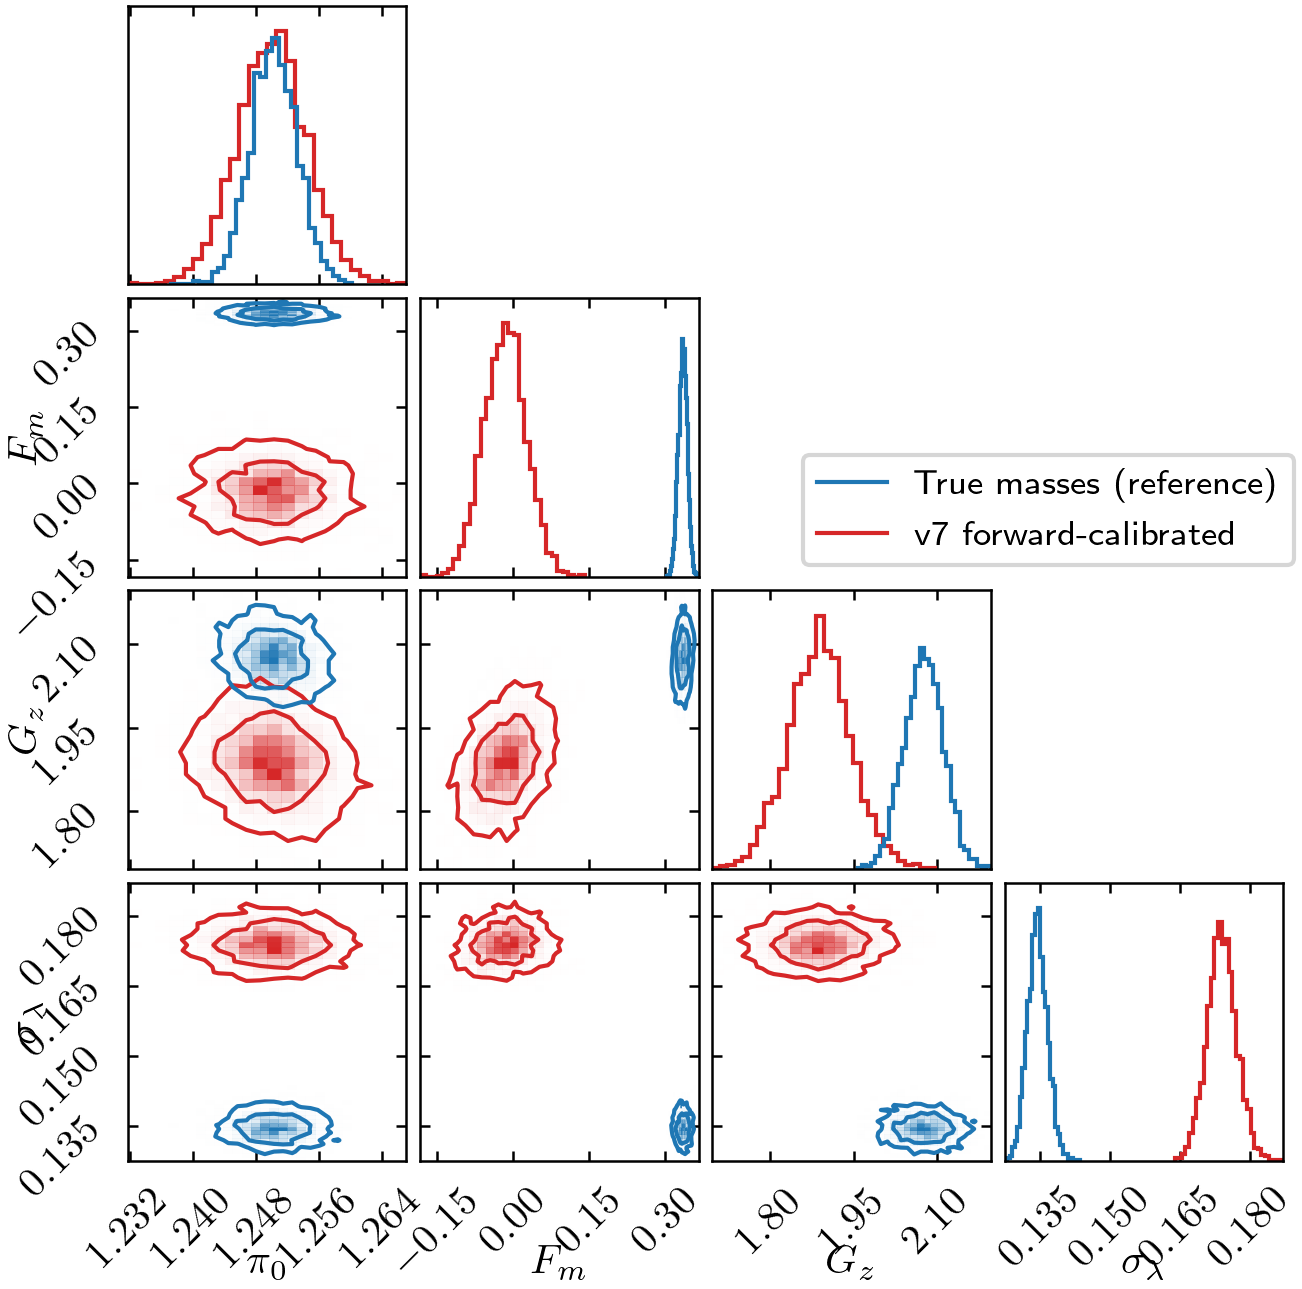

In [16]:
# Relation-parameter corner: v7 (C3) vs true-mass reference (C0)
fig = plt.figure(figsize=(4.5, 4.5))
labels = [r"$\pi_0$", r"$F_m$", r"$G_z$", r"$\sigma_\lambda$"]
keys = ['pi0', 'Fm', 'Gz', 'sigl']
corner.corner(np.vstack([samples[k] for k in keys]).T, labels=labels,
              levels=[0.68, 0.95], fig=fig, color='C3', hist_bin_factor=1.5,
              plot_datapoints=False, no_fill_contours=True)
corner.corner(np.vstack([truesamples[k] for k in keys]).T, labels=labels,
              levels=[0.68, 0.95], fig=fig, color='C0', hist_bin_factor=1.5,
              plot_datapoints=False, no_fill_contours=True)
plt.plot([], [], color='C0', label='True masses (reference)')
plt.plot([], [], color='C3', label='v7 forward-calibrated')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 2.6), fontsize='small')

Text(0.5, 0.98, 'Calibration parameters (black = injected truth)')

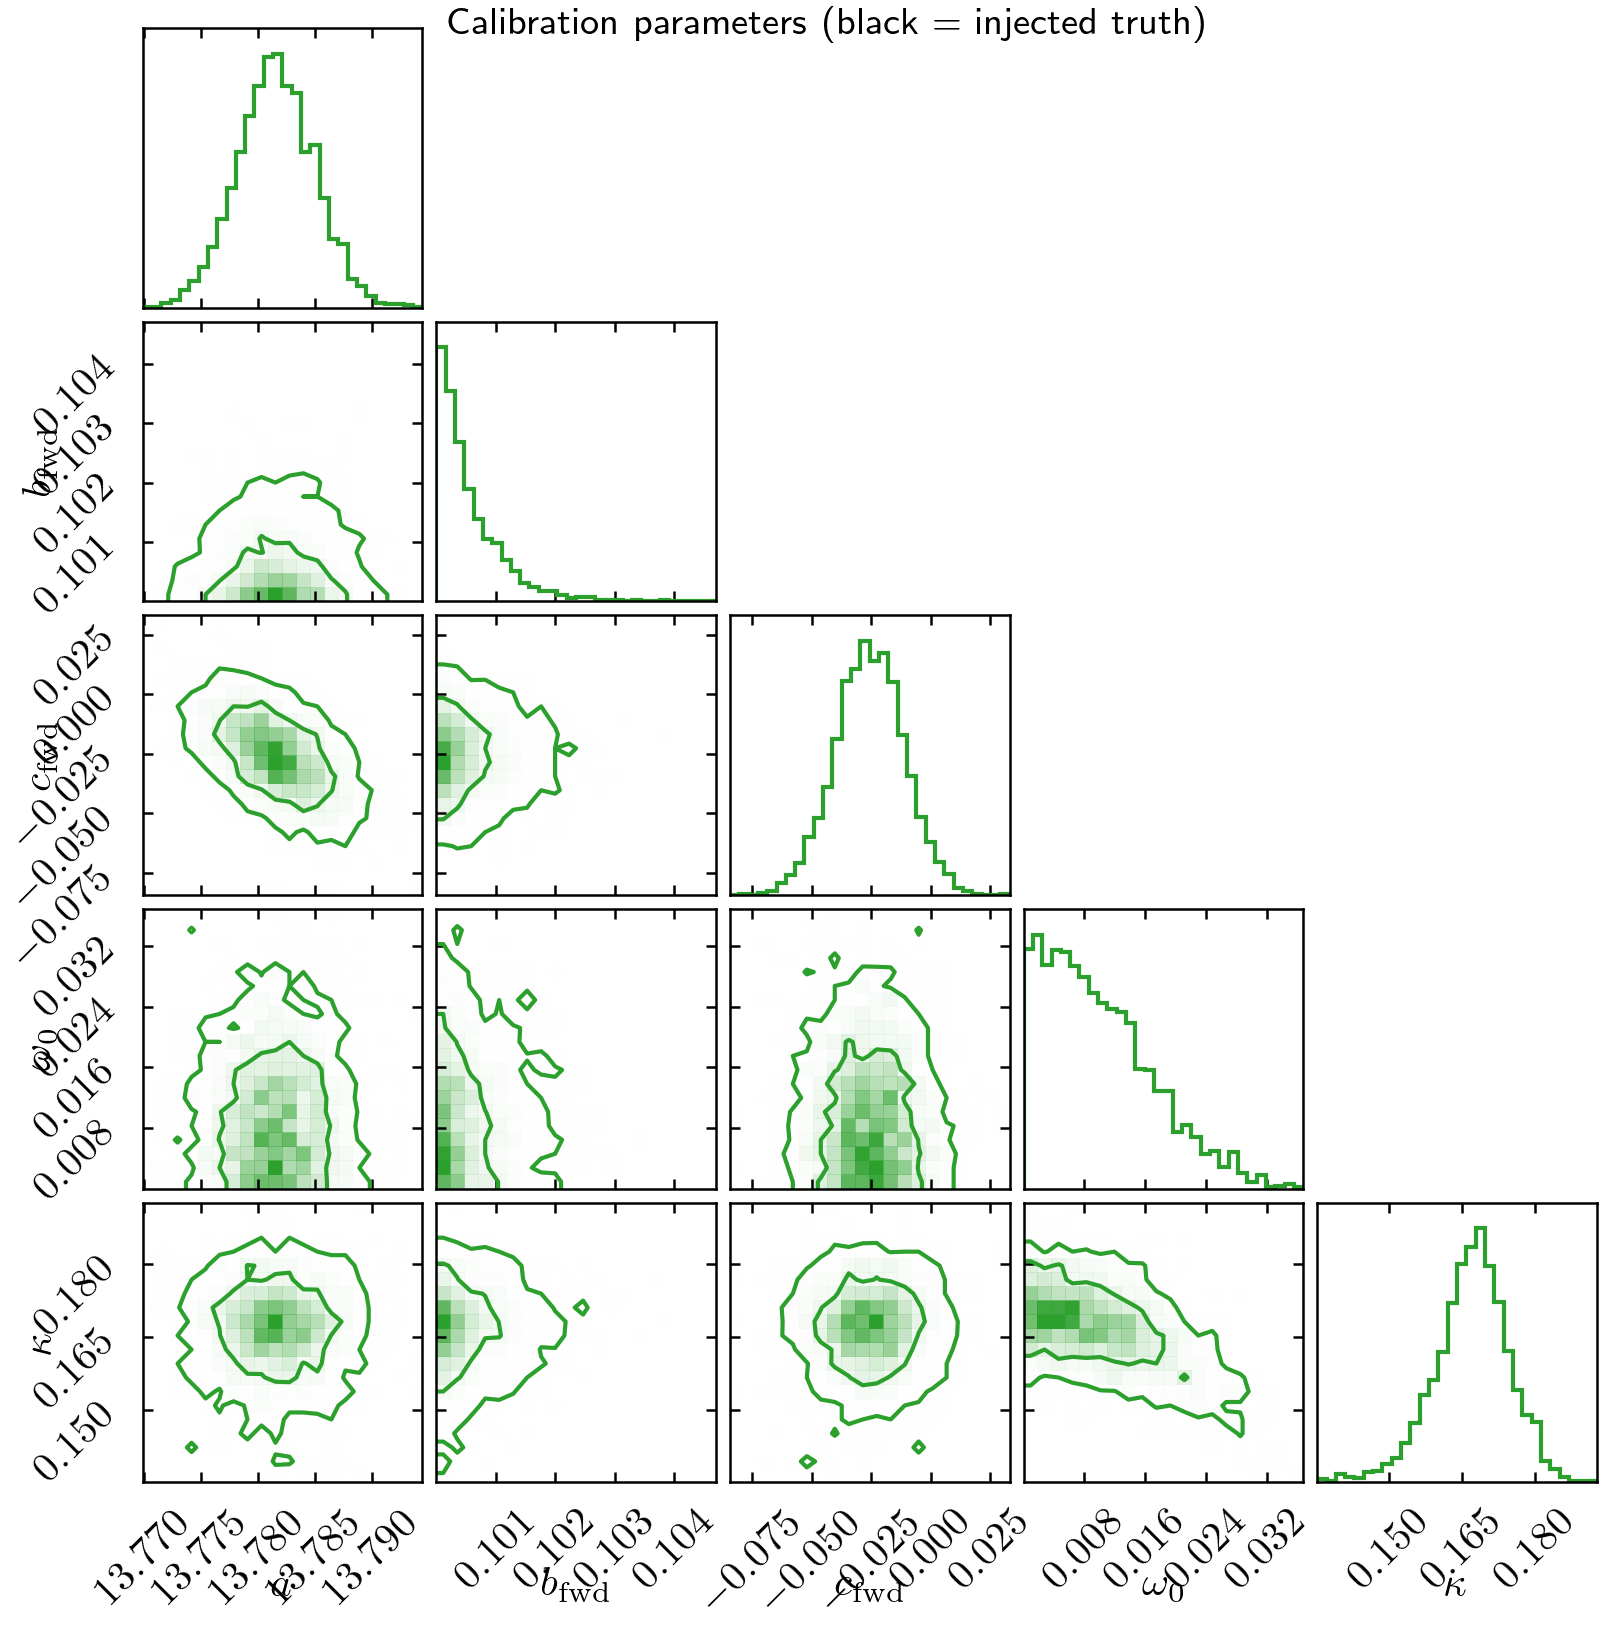

In [17]:
# Calibration-parameter corner; black lines = injected truth (if inject_bias)
fig = plt.figure(figsize=(5.5, 5.5))
labels = [r"$a$", r"$b_{\rm fwd}$",
          r"$c_{\rm fwd}$", r"$\omega_0$", r"$\kappa$"]
keys = ['a', 'b_fwd', 'c_fwd', 'omega0', 'kappa']
truths = ([a_star, b_star, c_star, omega0_star, kappa_star]
          if inject_bias else None)
corner.corner(np.vstack([samples[k] for k in keys]).T, labels=labels,
              levels=[0.68, 0.95], color='C2', hist_bin_factor=1.5,
              truths=truths, truth_color='k', fig=fig,
              plot_datapoints=False, no_fill_contours=True)
plt.suptitle('Calibration parameters (black = injected truth)', fontsize=9)

In [18]:
# Validation: grid vs Gaussian-pi CLOSED FORM. The closed form only applies to
# a LINEAR calibration channel, so we force c_fwd=0 here -- a quadrature
# regression test of the grid path (the quadratic mean uses the same machinery).
from scipy.special import logsumexp as _lse
p = {k: float(np.median(samples[k])) for k in
     ['pi0', 'Fm', 'Gz', 'sigl', 'a', 'b_fwd', 'c_fwd', 'omega0', 'kappa']}


def _lognorm(x, mean, sd):
    return -0.5*((x-mean)/sd)**2 - np.log(sd) - 0.5*np.log(2*np.pi)


# grid path (numpy), LINEAR (c_fwd = 0) to match the closed form
mg = m_grid[None, :]
om = np.sqrt(p['omega0']**2 + (p['kappa']*sig_main)**2)[:, None]
ln_pi = _lognorm(mg, mpi_main[:, None], sig_pi)
ln_c = _lognorm(mu_main[:, None], p['a'] + p['b_fwd']*(mg - m_ref), om)
ln_r = _lognorm(ell_main[:, None],
                p['pi0'] + p['Fm']*(mg - m0_v7) + p['Gz']*zeta_main[:, None],
                p['sigl'])
grid_ll = _lse(ln_pi + ln_c + ln_r, axis=1) - _lse(ln_pi + ln_c, axis=1)

# closed form (Gaussian pi, linear calibration)
om2 = p['omega0']**2 + (p['kappa']*sig_main)**2
x = m_ref + (mu_main - p['a'])/p['b_fwd']
v = om2 / p['b_fwd']**2
tau2 = 1.0/(1.0/v + 1.0/sig_pi**2)
mhat = tau2*(x/v + mpi_main/sig_pi**2)
mean_ell = p['pi0'] + p['Fm']*(mhat - m0_v7) + p['Gz']*zeta_main
var_ell = p['sigl']**2 + p['Fm']**2 * tau2
closed_ll = _lognorm(ell_main, mean_ell, np.sqrt(var_ell))

print(f'(linear sub-case) max |grid - closed| = '
      f'{np.max(np.abs(grid_ll-closed_ll)):.2e}')
print(f'sum grid={grid_ll.sum():.4f}, sum closed={closed_ll.sum():.4f}')

(linear sub-case) max |grid - closed| = 4.81e-11
sum grid=523.3943, sum closed=523.3943


peak(lambda only) = 13.675 vs m_rel = -19.976611169392783


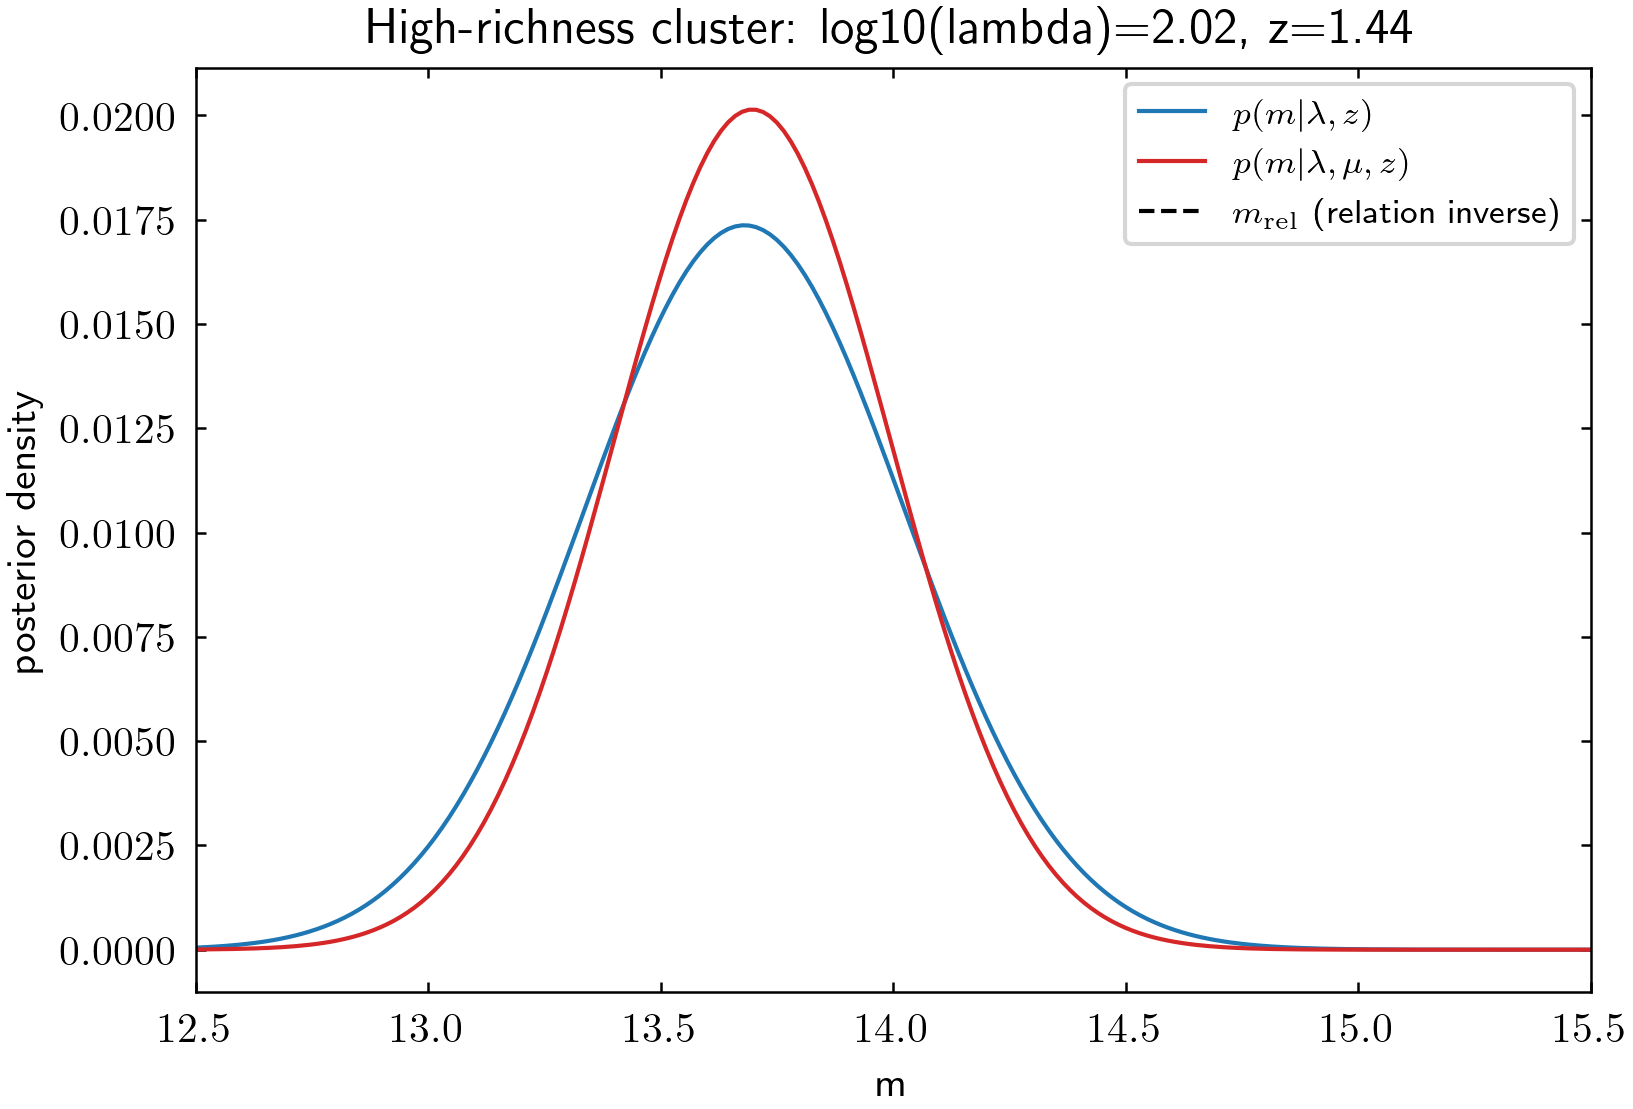

In [19]:
# Post-fit p(m_true | ell, z[, mu]) on the grid, and the Eddington check
def mass_posterior(ell, z, params, grid, mu=None, sigma=None):
    zeta_ = np.log10((1 + z)/(1 + z0))
    mpi_ = reg_phi.intercept_ + reg_phi.coef_[0]*zeta_
    lp = (_lognorm(grid, mpi_, sig_pi)
          + _lognorm(ell, params['pi0'] + params['Fm']*(grid - m0_v7)
                     + params['Gz']*zeta_, params['sigl']))
    if mu is not None:
        om_ = np.sqrt(params['omega0']**2 + (params['kappa']*sigma)**2)
        lp = lp + _lognorm(mu, params['a'] +
                           params['b_fwd']*(grid - m_ref), om_)
    lp -= _lse(lp)
    return np.exp(lp)


# pick a high-richness main cluster
j = np.argmax(ell_main)
z_j, ell_j, mu_j, sig_j = (zeta_main[j], ell_main[j], mu_main[j], sig_main[j])
zj = (1 + z0)*10**z_j - 1
# lambda only
post_l = mass_posterior(ell_j, zj, p, m_grid)
post_lm = mass_posterior(ell_j, zj, p, m_grid, mu=mu_j, sigma=sig_j)  # + mu
m_rel = m0_v7 + (ell_j - p['pi0'] - p['Gz']*z_j)/p['Fm']

f, ax = plt.subplots(figsize=(6, 4))
ax.plot(m_grid, post_l, 'C0', label=r'$p(m|\lambda,z)$')
ax.plot(m_grid, post_lm, 'C3', label=r'$p(m|\lambda,\mu,z)$')
ax.axvline(m_rel, color='k', ls='--',
           label=r'$m_{\rm rel}$ (relation inverse)')
ax.set_xlim(12.5, 15.5)
ax.set_xlabel('m')
ax.set_ylabel('posterior density')
ax.set_title(f'High-richness cluster: log10(lambda)={ell_j:.2f}, z={zj:.2f}')
ax.legend(fontsize=8)
print('peak(lambda only) =', m_grid[np.argmax(post_l)], 'vs m_rel =', m_rel)

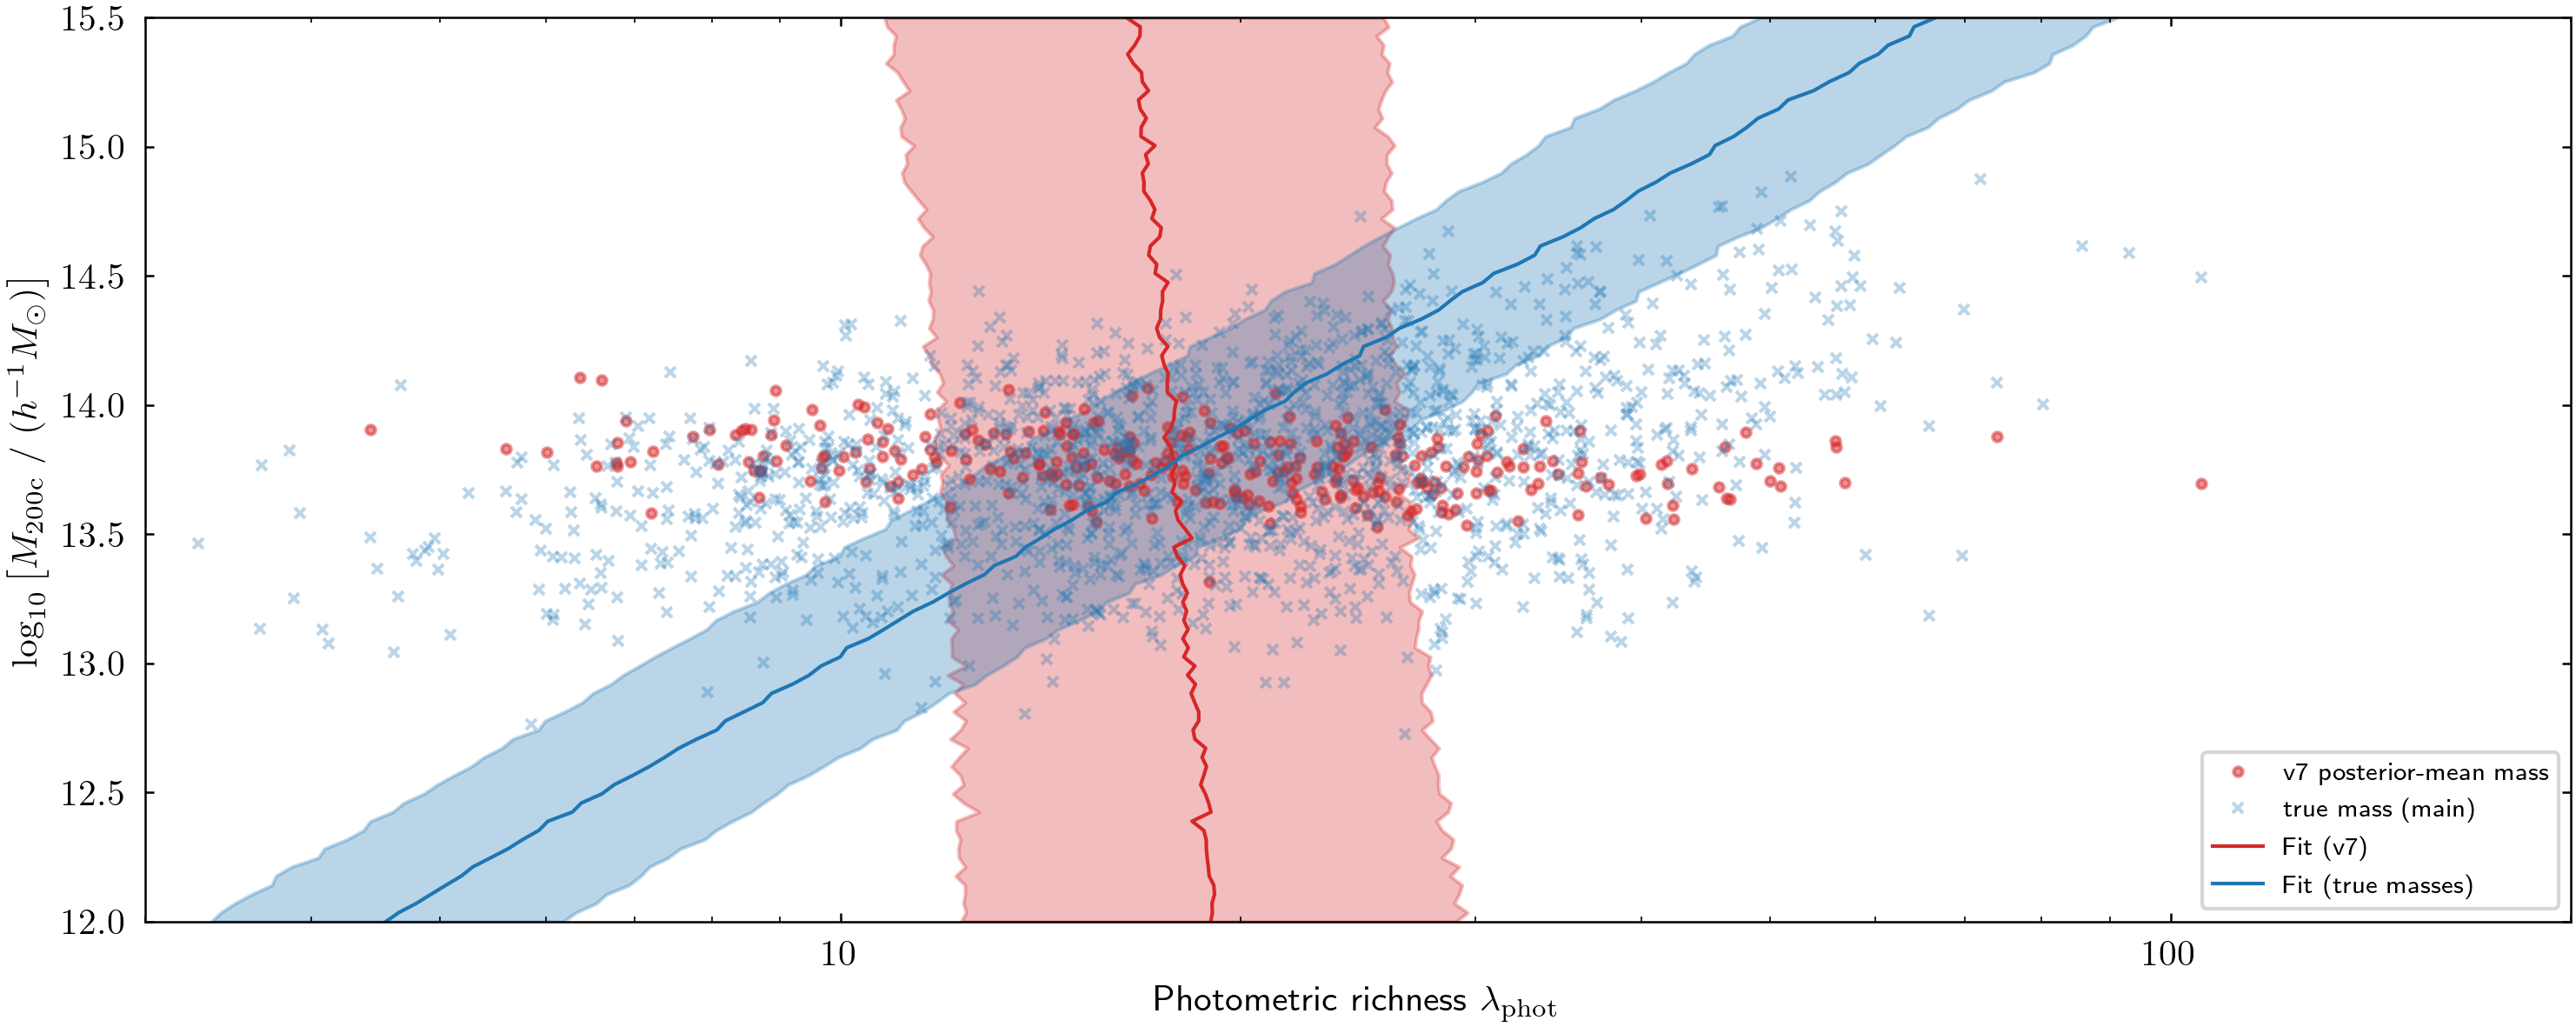

In [20]:
# Mass--richness fit: richness (x) vs M200c (y), v7 vs reference
f, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.semilogx()
# posterior-mean true mass for main clusters (lambda+mu), as points
mhat_main = np.array([np.sum(m_grid*mass_posterior(ell_main[i],
                      (1+z0)*10**zeta_main[i]-1, p, m_grid,
                      mu=mu_main[i], sigma=sig_main[i])) for i in range(0, len(ell_main), 5)])
ax.plot(10**ell_main[::5], mhat_main, '.', color='C3', alpha=0.5,
        label='v7 posterior-mean mass')
ax.plot(10**ell_main, ytrue[~is_cal], 'x', color='C0', ms=3, alpha=0.3,
        label='true mass (main)')

xm = np.linspace(12., 15.5, 100)
for s, color, lab in [(samples, 'C3', 'Fit (v7)'),
                      (truesamples, 'C0', 'Fit (true masses)')]:
    lines = relation_mean(xm[:, None], 0.0, m0_v7, s['pi0'], s['Fm'], s['Gz'])
    lines = lines + s['sigl']*np.random.randn(*lines.shape)
    pr = np.percentile(10**lines, [16, 50, 84], axis=1)
    ax.plot(pr[1], xm, c=color, label=lab)
    ax.fill_betweenx(xm, pr[0], pr[2], alpha=0.3, color=color)

ax.set_xlim(3, 200)
ax.set_ylim(12., 15.5)
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel(r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(loc='lower right', fontsize=7)